# Cost_Analysis



## Startup cells

In [0]:
# Set environment variables for sagemaker_studio imports

import os
os.environ['DataZoneProjectId'] = 'cxd5ximkhsltpl'
os.environ['DataZoneDomainId'] = 'dzd-4brc9qkp2k7js9'
os.environ['DataZoneEnvironmentId'] = '3wsbalq783302x'
os.environ['DataZoneDomainRegion'] = 'us-east-2'

# create both a function and variable for metadata access
_resource_metadata = None

def _get_resource_metadata():
    global _resource_metadata
    if _resource_metadata is None:
        _resource_metadata = {
            "AdditionalMetadata": {
                "DataZoneProjectId": "cxd5ximkhsltpl",
                "DataZoneDomainId": "dzd-4brc9qkp2k7js9",
                "DataZoneEnvironmentId": "3wsbalq783302x",
                "DataZoneDomainRegion": "us-east-2",
            }
        }
    return _resource_metadata
metadata = _get_resource_metadata()

In [0]:
"""
Logging Configuration

Purpose:
--------
This sets up the logging framework for code executed in the user namespace.
"""

from typing import Optional


def _set_logging(log_dir: str, log_file: str, log_name: Optional[str] = None):
    import os
    import logging
    from logging.handlers import RotatingFileHandler

    level = logging.INFO
    max_bytes = 5 * 1024 * 1024
    backup_count = 5

    # fallback to /tmp dir on access, helpful for local dev setup
    try:
        os.makedirs(log_dir, exist_ok=True)
    except Exception:
        log_dir = "/tmp/kernels/"

    os.makedirs(log_dir, exist_ok=True)
    log_path = os.path.join(log_dir, log_file)

    logger = logging.getLogger() if not log_name else logging.getLogger(log_name)
    logger.handlers = []
    logger.setLevel(level)

    formatter = logging.Formatter("%(asctime)s - %(name)s - %(levelname)s - %(message)s")

    # Rotating file handler
    fh = RotatingFileHandler(filename=log_path, maxBytes=max_bytes, backupCount=backup_count, encoding="utf-8")
    fh.setFormatter(formatter)
    logger.addHandler(fh)

    logger.info(f"Logging initialized for {log_name}.")


_set_logging("/var/log/computeEnvironments/kernel/", "kernel.log")
_set_logging("/var/log/studio/data-notebook-kernel-server/", "metrics.log", "metrics")

In [0]:
import logging
from sagemaker_studio import ClientConfig, sqlutils, sparkutils, dataframeutils

logger = logging.getLogger(__name__)
logger.info("Initializing sparkutils")
spark = sparkutils.init()
logger.info("Finished initializing sparkutils")

In [0]:
def _reset_os_path():
    """
    Reset the process's working directory to handle mount timing issues.
    
    This function resolves a race condition where the Python process starts
    before the filesystem mount is complete, causing the process to reference
    old mount paths and inodes. By explicitly changing to the mounted directory
    (/home/sagemaker-user), we ensure the process uses the correct, up-to-date
    mount point.
    
    The function logs stat information (device ID and inode) before and after
    the directory change to verify that the working directory is properly
    updated to reference the new mount.
    
    Note:
        This is executed at module import time to ensure the fix is applied
        as early as possible in the kernel initialization process.
    """
    try:
        import os
        import logging

        logger = logging.getLogger(__name__)
        logger.info("---------Before------")
        logger.info("CWD: %s", os.getcwd())
        logger.info("stat('.'): %s %s", os.stat('.').st_dev, os.stat('.').st_ino)
        logger.info("stat('/home/sagemaker-user'): %s %s", os.stat('/home/sagemaker-user').st_dev, os.stat('/home/sagemaker-user').st_ino)

        os.chdir("/home/sagemaker-user")

        logger.info("---------After------")
        logger.info("CWD: %s", os.getcwd())
        logger.info("stat('.'): %s %s", os.stat('.').st_dev, os.stat('.').st_ino)
        logger.info("stat('/home/sagemaker-user'): %s %s", os.stat('/home/sagemaker-user').st_dev, os.stat('/home/sagemaker-user').st_ino)
    except Exception as e:
        logger.exception(f"Failed to reset working directory: {e}")

_reset_os_path()

## Notebook

In [0]:
import boto3

glue_client = boto3.client('glue')

# Configuration
database_name = 'maximus_cur_db'
table_name = 'mms_resources_cost'
s3_location = 's3://amazon-sagemaker-423014875898-us-east-2-cxd5ximkhsltpl/curfiles/'

print("=" * 80)
print("Creating Table from CSV Columns")
print("=" * 80)

# Check if we have csv_columns from previous cell
if 'csv_columns' not in locals() or csv_columns is None:
    print("⚠️  No csv_columns found. Please run the previous cell first.")
else:
    # Convert CSV column names to Glue table columns (all STRING type for simplicity)
    # Normalize column names: replace "/" and special chars with underscores
    glue_columns = []
    for col in csv_columns:
        normalized_col = col.replace('/', '_').replace(':', '_').lower()
        glue_columns.append({'Name': normalized_col, 'Type': 'string'})
    
    print(f"✅ Prepared {len(glue_columns)} columns for table")
    
    # Check if table exists
    try:
        glue_client.get_table(DatabaseName=database_name, Name=table_name)
        print(f"⚠️  Table {table_name} already exists. Skipping creation.")
        print(f"   To recreate, delete it first.")
    except glue_client.exceptions.EntityNotFoundException:
        # Table doesn't exist, create it
        table_input = {
            'Name': table_name,
            'StorageDescriptor': {
                'Columns': glue_columns,
                'Location': s3_location,
                'InputFormat': 'org.apache.hadoop.mapred.TextInputFormat',
                'OutputFormat': 'org.apache.hadoop.hive.ql.io.HiveIgnoreKeyTextOutputFormat',
                'Compressed': False,
                'SerdeInfo': {
                    'SerializationLibrary': 'org.apache.hadoop.hive.serde2.OpenCSVSerde',
                    'Parameters': {
                        'separatorChar': ',',
                        'quoteChar': '"',
                        'escapeChar': '\\\\'
                    }
                }
            },
            'Parameters': {
                'has_encrypted_data': 'false',
                'skip.header.line.count': '1',
                'use.null.for.invalid.data': 'true'
            },
            'TableType': 'EXTERNAL_TABLE'
        }
        
        try:
            glue_client.create_table(
                DatabaseName=database_name,
                TableInput=table_input
            )
            print(f"\n✅ Table created successfully!")
            print(f"   Database: {database_name}")
            print(f"   Table: {table_name}")
            print(f"   Location: {s3_location}")
            print(f"   Columns: {len(glue_columns)}")
            print(f"   SerDe: OpenCSVSerde")
            
        except Exception as e:
            print(f"\n❌ Error creating table: {e}")
    
    except Exception as e:
        print(f"❌ Error checking table: {e}")

print("=" * 80)

Creating Table from CSV Columns
✅ Prepared 104 columns for table
⚠️  Table mms_resources_cost already exists. Skipping creation.
   To recreate, delete it first.


In [0]:
import boto3

glue_client = boto3.client('glue')

# Update table to exclude manifest files and handle bad data
database_name = 'maximus_cur_db'
table_name = 'mms_resources_cost'

print("=" * 80)
print("Updating Table to Exclude Manifest Files")
print("=" * 80)

# Get existing table
try:
    response = glue_client.get_table(
        DatabaseName=database_name,
        Name=table_name
    )
    table = response['Table']
    
    # Update table parameters to handle invalid data
    if 'Parameters' not in table:
        table['Parameters'] = {}
    
    table['Parameters']['use.null.for.invalid.data'] = 'true'
    table['Parameters']['skip.header.line.count'] = '1'
    table['Parameters']['has_encrypted_data'] = 'false'
    
    # Update SerDe to exclude manifest files by updating the location pattern
    storage_descriptor = table['StorageDescriptor']
    
    # Update location to point only to CSV files by using a more specific pattern
    # We'll update the SerDe parameters to be more lenient
    if 'Parameters' not in storage_descriptor['SerdeInfo']:
        storage_descriptor['SerdeInfo']['Parameters'] = {}
    
    storage_descriptor['SerdeInfo']['Parameters']['separatorChar'] = ','
    storage_descriptor['SerdeInfo']['Parameters']['quoteChar'] = '"'
    storage_descriptor['SerdeInfo']['Parameters']['escapeChar'] = '\\\\'
    
    # Create table input for update
    table_input = {
        'Name': table['Name'],
        'StorageDescriptor': storage_descriptor,
        'Parameters': table['Parameters'],
        'TableType': table.get('TableType', 'EXTERNAL_TABLE')
    }
    
    # Add partition keys if they exist
    if 'PartitionKeys' in table:
        table_input['PartitionKeys'] = table['PartitionKeys']
    
    # Update the table
    glue_client.update_table(
        DatabaseName=database_name,
        TableInput=table_input
    )
    
    print(f"✅ Table updated successfully!")
    print(f"   Added parameter: use.null.for.invalid.data = true")
    print(f"   This will treat invalid/manifest data as NULL")
    
except Exception as e:
    print(f"❌ Error updating table: {e}")

print("=" * 80)
print("\n💡 Now let's query only the CSV files by pattern...")

Updating Table to Exclude Manifest Files
✅ Table updated successfully!
   Added parameter: use.null.for.invalid.data = true
   This will treat invalid/manifest data as NULL

💡 Now let's query only the CSV files by pattern...


In [0]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sagemaker_studio.utils import sqlutils
from datetime import datetime, timedelta

# Configuration: Set the number of months to analyze (15 to 48)
MONTHS_TO_ANALYZE = 24  # Change this value between 15 and 48

# Calculate start date based on months
months_ago_date = (datetime.now() - timedelta(days=MONTHS_TO_ANALYZE * 30)).strftime('%Y-%m-%d')

print(f"📅 Configuration: Analyzing last {MONTHS_TO_ANALYZE} months")
print(f"   Start date: {months_ago_date}")
print(f"   End date: {datetime.now().strftime('%Y-%m-%d')}")

# Query with aggregation in SQL for better performance
query = f"""
SELECT 
    lineitem_usageaccountid AS account_id,
    product_servicename AS resource_type,
    SUBSTR(bill_billingperiodstartdate, 1, 7) AS billing_period,
    SUM(CAST(lineitem_unblendedcost AS DOUBLE)) AS cost
FROM maximus_cur_db.mms_resources_cost
WHERE lineitem_unblendedcost IS NOT NULL 
  AND lineitem_usageaccountid IS NOT NULL
  AND lineitem_usageaccountid NOT LIKE '%type%'
  AND TRY_CAST(lineitem_unblendedcost AS DOUBLE) IS NOT NULL
  AND product_servicename IS NOT NULL
  AND bill_billingperiodstartdate >= '{months_ago_date}'
GROUP BY 
    lineitem_usageaccountid,
    product_servicename,
    SUBSTR(bill_billingperiodstartdate, 1, 7)
HAVING SUM(CAST(lineitem_unblendedcost AS DOUBLE)) > 0
ORDER BY billing_period DESC, cost DESC
"""

print("\n⏳ Querying CUR data (aggregated by account, service, and period)...")
print("   This may take a few minutes for large datasets...")

df = sqlutils.sql(query, connection_id='b7c0s9hkmrvsmh')

if df is not None and len(df) > 0:
    print(f"\n✅ Query successful! Retrieved {len(df):,} aggregated rows")
    
    # Convert billing_period to datetime
    df['billing_period'] = pd.to_datetime(df['billing_period'])
    
    # Sort by date
    df = df.sort_values('billing_period')
    
    print(f"\n📊 Data summary:")
    print(f"   Date range: {df['billing_period'].min().strftime('%Y-%m')} to {df['billing_period'].max().strftime('%Y-%m')}")
    print(f"   Time span: {(df['billing_period'].max() - df['billing_period'].min()).days} days ({df['billing_period'].nunique()} months)")
    print(f"   Accounts: {df['account_id'].nunique()}")
    print(f"   Services: {df['resource_type'].nunique()}")
    print(f"   Total cost: ${df['cost'].sum():,.2f}")
    print(f"   Avg monthly cost: ${df.groupby('billing_period')['cost'].sum().mean():,.2f}")
    
    # Validation check
    actual_periods = df['billing_period'].nunique()
    if actual_periods < 15:
        print(f"\n⚠️  Warning: Only {actual_periods} periods found. Minimum recommended is 15 for reliable anomaly detection.")
    elif actual_periods > 48:
        print(f"\n⚠️  Note: {actual_periods} periods found. Consider reducing MONTHS_TO_ANALYZE for faster processing.")
    else:
        print(f"\n✅ Period count ({actual_periods}) is optimal for analysis (15-48 range)")
    
    df.head(10)
else:
    print("❌ No data returned")

📅 Configuration: Analyzing last 24 months
   Start date: 2023-12-25
   End date: 2025-12-14

⏳ Querying CUR data (aggregated by account, service, and period)...
   This may take a few minutes for large datasets...



✅ Query successful! Retrieved 507 aggregated rows

📊 Data summary:
   Date range: 2024-01 to 2025-03
   Time span: 425 days (15 months)
   Accounts: 31
   Services: 30
   Total cost: $6,946.83
   Avg monthly cost: $463.12

✅ Period count (15) is optimal for analysis (15-48 range)


In [0]:
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
import numpy as np
import pickle
import os
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Initialize global model storage
MODEL_STORAGE = {}

def train_and_save_model(df, account_id, service, model_dir='models'):
    """
    Trains a model for specific account-service combination and saves it with metadata.
    The model learns patterns and improves over time.
    """
    # Filter data for specific account and service
    service_df = df[(df['account_id'] == account_id) & (df['resource_type'] == service)].sort_values('billing_period').reset_index(drop=True)
    
    if service_df.empty or len(service_df) < 3:
        return None, None
    
    # Aggregate costs by billing period (sum up all line items)
    service_df = service_df.groupby('billing_period').agg({'cost': 'sum'}).reset_index()
    service_df.columns = ['billing_period', 'Total_Cost']
    
    # Feature engineering with proper handling of edge cases
    service_df['moving_avg_3'] = service_df['Total_Cost'].rolling(window=3, min_periods=1).mean()
    service_df['moving_avg_6'] = service_df['Total_Cost'].rolling(window=6, min_periods=1).mean()
    service_df['rolling_std'] = service_df['Total_Cost'].rolling(window=3, min_periods=1).std().fillna(0)
    service_df['cost_change'] = service_df['Total_Cost'].diff().fillna(0)
    
    # Handle percentage change carefully to avoid infinity
    service_df['cost_pct_change'] = service_df['Total_Cost'].pct_change().fillna(0) * 100
    # Replace infinity values with 0
    service_df['cost_pct_change'] = service_df['cost_pct_change'].replace([np.inf, -np.inf], 0)
    
    # Create feature matrix
    features = service_df[['Total_Cost', 'moving_avg_3', 'moving_avg_6', 'rolling_std', 'cost_change', 'cost_pct_change']].values
    
    # Additional safety check: replace any remaining inf/nan with 0
    features = np.nan_to_num(features, nan=0.0, posinf=0.0, neginf=0.0)
    
    # Standardize features for better model performance
    scaler = StandardScaler()
    features_scaled = scaler.fit_transform(features)
    
    # Train Isolation Forest with learned patterns
    iso_forest = IsolationForest(
        contamination=0.1,
        random_state=42,
        n_estimators=100,
        max_samples='auto',
        bootstrap=True
    )
    service_df['anomaly'] = iso_forest.fit_predict(features_scaled)
    service_df['anomaly_score'] = iso_forest.score_samples(features_scaled)
    
    # Calculate statistical profile for this account-service
    profile = {
        'mean_cost': service_df['Total_Cost'].mean(),
        'std_cost': service_df['Total_Cost'].std(),
        'median_cost': service_df['Total_Cost'].median(),
        'min_cost': service_df['Total_Cost'].min(),
        'max_cost': service_df['Total_Cost'].max(),
        'training_samples': len(service_df),
        'last_updated': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
        'account_id': account_id,
        'service': service
    }
    
    # Store model and metadata
    model_key = f"{account_id}_{service}"
    MODEL_STORAGE[model_key] = {
        'model': iso_forest,
        'scaler': scaler,
        'profile': profile,
        'feature_names': ['Total_Cost', 'moving_avg_3', 'moving_avg_6', 'rolling_std', 'cost_change', 'cost_pct_change']
    }
    
    # -1 indicates anomaly, 1 indicates normal
    anomalies = service_df[service_df['anomaly'] == -1]
    
    return service_df, anomalies

def detect_anomalies_with_learning(df, account_id, service):
    """Enhanced anomaly detection with learning capability."""
    return train_and_save_model(df, account_id, service)

def get_model_summary():
    """Returns summary of all trained models."""
    summary = []
    for key, model_data in MODEL_STORAGE.items():
        profile = model_data['profile']
        summary.append({
            'Account_Service': key,
            'Training_Samples': profile['training_samples'],
            'Mean_Cost': f"${profile['mean_cost']:.2f}",
            'Std_Dev': f"${profile['std_cost']:.2f}",
            'Last_Updated': profile['last_updated']
        })
    return pd.DataFrame(summary)

def save_models_to_disk(model_dir='models'):
    """Saves all trained models to disk for persistence."""
    os.makedirs(model_dir, exist_ok=True)
    
    for key, model_data in MODEL_STORAGE.items():
        file_path = os.path.join(model_dir, f"{key}_model.pkl")
        with open(file_path, 'wb') as f:
            pickle.dump(model_data, f)
    
    print(f"✓ Saved {len(MODEL_STORAGE)} models to '{model_dir}/' directory")
    return len(MODEL_STORAGE)

def load_models_from_disk(model_dir='models'):
    """Loads previously trained models from disk."""
    if not os.path.exists(model_dir):
        print(f"No model directory found at '{model_dir}/'")
        return 0
    
    count = 0
    for file_name in os.listdir(model_dir):
        if file_name.endswith('_model.pkl'):
            file_path = os.path.join(model_dir, file_name)
            with open(file_path, 'rb') as f:
                key = file_name.replace('_model.pkl', '')
                MODEL_STORAGE[key] = pickle.load(f)
                count += 1
    
    print(f"✓ Loaded {count} models from '{model_dir}/' directory")
    return count

# Keep backward compatibility
detect_anomalies_with_isolation_forest = detect_anomalies_with_learning

print("✓ Machine Learning functions loaded successfully")
print("✓ Models will learn and adapt to each account-service usage pattern")
print("✓ Use save_models_to_disk() to persist models")
print("✓ Use load_models_from_disk() to reload saved models")

✓ Machine Learning functions loaded successfully
✓ Models will learn and adapt to each account-service usage pattern
✓ Use save_models_to_disk() to persist models
✓ Use load_models_from_disk() to reload saved models


Detecting anomalies with Machine Learning (threshold: >10% AND >$100)...




ANOMALY DETECTION SUMMARY (ML-Powered)
Total accounts analyzed: 31
Accounts with anomalies: 1
ML Models trained: 22
Thresholds: >10% deviation AND >$100 dollars


################################################################################
ACCOUNT: 794038217374
################################################################################
Services with anomalies: 1

  → Service: 
    Anomalies detected: 1
    Anomaly periods:
      - 2024-11: $551.54 (+54.7%, $195.05) ↑ INCREASE



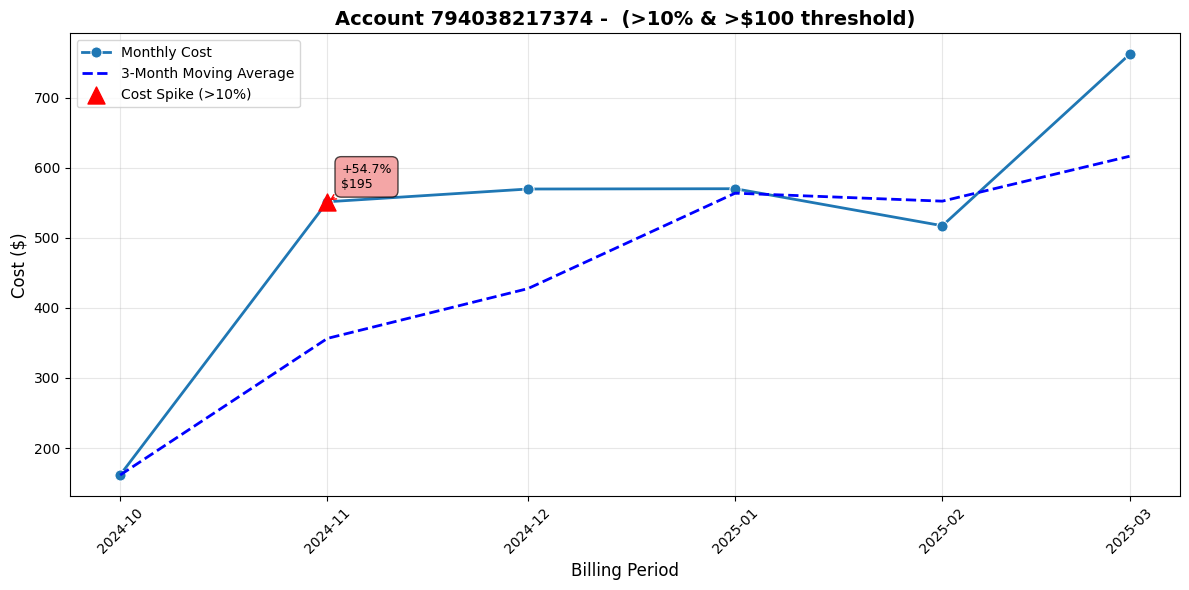

    Min Cost: $161.45 | Max Cost: $761.98

--------------------------------------------------------------------------------


SUMMARY TABLE: Accounts with Anomalies (>10% & >$100)
  Account_ID Service  Anomaly_Count Latest_Anomaly
794038217374                      1        2024-11


MACHINE LEARNING MODEL SUMMARY
Total models trained: 22
Thresholds: >10% deviation AND >$100 dollars

To view detailed model profiles, run: get_model_summary()
To save models for future use, run: save_models_to_disk()
To change thresholds:
  - ANOMALY_THRESHOLD_PERCENT = <percentage>
  - ANOMALY_THRESHOLD_DOLLARS = <amount>


In [0]:
# Configuration: Minimum thresholds for anomalies
ANOMALY_THRESHOLD_DOLLARS = 100  # Ignore anomalies with absolute deviation < $50
ANOMALY_THRESHOLD_PERCENT = 10  # Ignore anomalies with deviation < 10% from moving average

# Find all accounts with anomalies and aggregate by account
print(f"Detecting anomalies with Machine Learning (threshold: >{ANOMALY_THRESHOLD_PERCENT}% AND >${ANOMALY_THRESHOLD_DOLLARS})...\n")

# Dictionary to store anomaly results by account
account_anomalies = {}

# Process each account-service combination and train models
unique_combos = df.groupby(['account_id', 'resource_type']).size().reset_index(name='count')

for idx, row in unique_combos.iterrows():
    account_id = row['account_id']
    service = row['resource_type']
    
    # Use learning-enabled detection (trains model for each account-service)
    result = detect_anomalies_with_learning(df, account_id, service)
    
    if result[0] is not None:
        service_df, anomalies = result
        
        # Filter anomalies based on percentage and dollar thresholds
        if not anomalies.empty:
            # Calculate deviation percentage and absolute dollar amount
            anomalies['deviation_pct'] = ((anomalies['Total_Cost'] - anomalies['moving_avg_3']) / anomalies['moving_avg_3']) * 100
            anomalies['deviation_pct'] = anomalies['deviation_pct'].fillna(0)
            anomalies['deviation_dollars'] = abs(anomalies['Total_Cost'] - anomalies['moving_avg_3'])
            
            # Filter: must exceed BOTH percentage AND dollar thresholds
            anomalies = anomalies[
                (anomalies['deviation_pct'].abs() >= ANOMALY_THRESHOLD_PERCENT) & 
                (anomalies['deviation_dollars'] >= ANOMALY_THRESHOLD_DOLLARS)
            ]
        
        # If anomalies found after filtering, add to account tracking
        if not anomalies.empty:
            if account_id not in account_anomalies:
                account_anomalies[account_id] = []
            
            account_anomalies[account_id].append({
                'service': service,
                'anomaly_count': len(anomalies),
                'anomaly_dates': anomalies['billing_period'].tolist(),
                'anomaly_costs': anomalies['Total_Cost'].tolist(),
                'service_df': service_df,
                'anomalies_df': anomalies
            })

# Display summary
print(f"\n{'='*80}")
print(f"ANOMALY DETECTION SUMMARY (ML-Powered)")
print(f"{'='*80}")
print(f"Total accounts analyzed: {df['account_id'].nunique()}")
print(f"Accounts with anomalies: {len(account_anomalies)}")
print(f"ML Models trained: {len(MODEL_STORAGE)}")
print(f"Thresholds: >{ANOMALY_THRESHOLD_PERCENT}% deviation AND >${ANOMALY_THRESHOLD_DOLLARS} dollars")
print(f"{'='*80}\n")

# Display details and graphs for each account with anomalies
for account_id, services_data in sorted(account_anomalies.items()):
    print(f"\n{'#'*80}")
    print(f"ACCOUNT: {account_id}")
    print(f"{'#'*80}")
    print(f"Services with anomalies: {len(services_data)}\n")
    
    for service_info in services_data:
        print(f"  → Service: {service_info['service']}")
        print(f"    Anomalies detected: {service_info['anomaly_count']}")
        print(f"    Anomaly periods:")
        
        service_df = service_info['service_df']
        anomalies = service_info['anomalies_df']
        
        for idx, row in anomalies.iterrows():
            deviation_pct = ((row['Total_Cost'] - row['moving_avg_3']) / row['moving_avg_3']) * 100 if row['moving_avg_3'] > 0 else 0
            deviation_dollars = abs(row['Total_Cost'] - row['moving_avg_3'])
            anomaly_type = "↓ DECREASE" if deviation_pct < 0 else "↑ INCREASE"
            print(f"      - {row['billing_period'].strftime('%Y-%m')}: ${row['Total_Cost']:.2f} ({deviation_pct:+.1f}%, ${deviation_dollars:.2f}) {anomaly_type}")
        print()
        
        # Separate anomalies into increases and decreases
        anomalies_increase = anomalies[anomalies['deviation_pct'] > 0]
        anomalies_decrease = anomalies[anomalies['deviation_pct'] < 0]
        
        # Generate graph
        plt.figure(figsize=(12, 6))
        sns.lineplot(data=service_df, x='billing_period', y='Total_Cost', marker='o', label='Monthly Cost', linewidth=2, markersize=8)
        plt.plot(service_df['billing_period'], service_df['moving_avg_3'], color='blue', linestyle='--', linewidth=2, label='3-Month Moving Average')
        
        # Highlight anomalies - RED for increases, GREEN for decreases
        if not anomalies_increase.empty:
            plt.scatter(anomalies_increase['billing_period'], anomalies_increase['Total_Cost'], 
                       color='red', s=150, zorder=5, label=f'Cost Spike (>{ANOMALY_THRESHOLD_PERCENT}%)', marker='^')
        
        if not anomalies_decrease.empty:
            plt.scatter(anomalies_decrease['billing_period'], anomalies_decrease['Total_Cost'], 
                       color='green', s=150, zorder=5, label=f'Cost Drop (>{ANOMALY_THRESHOLD_PERCENT}%)', marker='v')
        
        # Annotate all anomalies with appropriate colors
        for idx, row in anomalies.iterrows():
            deviation_pct = ((row['Total_Cost'] - row['moving_avg_3']) / row['moving_avg_3']) * 100 if row['moving_avg_3'] > 0 else 0
            deviation_dollars = abs(row['Total_Cost'] - row['moving_avg_3'])
            
            # Choose annotation color based on direction
            annotation_color = 'lightcoral' if deviation_pct > 0 else 'lightgreen'
            
            plt.annotate(f"{deviation_pct:+.1f}%\n${deviation_dollars:.0f}", 
                        xy=(row['billing_period'], row['Total_Cost']),
                        xytext=(10, 10) if deviation_pct > 0 else (10, -30),  # Position based on direction
                        textcoords='offset points',
                        bbox=dict(boxstyle='round,pad=0.5', fc=annotation_color, alpha=0.7),
                        arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0', 
                                      color='red' if deviation_pct > 0 else 'green'),
                        fontsize=9)
        
        plt.title(f'Account {account_id} - {service_info["service"]} (>{ANOMALY_THRESHOLD_PERCENT}% & >${ANOMALY_THRESHOLD_DOLLARS} threshold)', 
                 fontsize=14, fontweight='bold')
        plt.xlabel('Billing Period', fontsize=12)
        plt.ylabel('Cost ($)', fontsize=12)
        plt.legend(loc='best', fontsize=10)
        plt.grid(True, alpha=0.3)
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()
        
        print(f"    Min Cost: ${service_df['Total_Cost'].min():.2f} | Max Cost: ${service_df['Total_Cost'].max():.2f}")
        print()
    
    print(f"{'-'*80}\n")

# Create summary dataframe
if account_anomalies:
    summary_data = []
    for account_id, services_data in account_anomalies.items():
        for service_info in services_data:
            summary_data.append({
                'Account_ID': account_id,
                'Service': service_info['service'],
                'Anomaly_Count': service_info['anomaly_count'],
                'Latest_Anomaly': max(service_info['anomaly_dates']).strftime('%Y-%m') if service_info['anomaly_dates'] else 'N/A'
            })
    
    summary_df = pd.DataFrame(summary_data)
    print(f"\n{'='*80}")
    print(f"SUMMARY TABLE: Accounts with Anomalies (>{ANOMALY_THRESHOLD_PERCENT}% & >${ANOMALY_THRESHOLD_DOLLARS})")
    print(f"{'='*80}")
    print(summary_df.to_string(index=False))
else:
    print(f"\nNo anomalies detected above {ANOMALY_THRESHOLD_PERCENT}% and ${ANOMALY_THRESHOLD_DOLLARS} thresholds.")

# Display model learning summary
print(f"\n\n{'='*80}")
print("MACHINE LEARNING MODEL SUMMARY")
print(f"{'='*80}")
print(f"Total models trained: {len(MODEL_STORAGE)}")
print(f"Thresholds: >{ANOMALY_THRESHOLD_PERCENT}% deviation AND >${ANOMALY_THRESHOLD_DOLLARS} dollars")
print("\nTo view detailed model profiles, run: get_model_summary()")
print("To save models for future use, run: save_models_to_disk()")
print(f"To change thresholds:")
print(f"  - ANOMALY_THRESHOLD_PERCENT = <percentage>")
print(f"  - ANOMALY_THRESHOLD_DOLLARS = <amount>")
print(f"{'='*80}")

## Shutdown cells

In [0]:
"""
Stop spark session and associated Athena Spark session
"""

from IPython import get_ipython as _get_ipython
_get_ipython().user_ns["spark"].stop()